# Experimental analyses on top of the control tree

`tealtools.experimental` is a sandbox of analyses built on
`tealtools.control_tree`. The structural fold framework
(`tree_fold.TreeFold`) lets each analysis be ~50 lines of per-region
handlers — no recursion, no worklist plumbing.

| Module | What it gives you |
|---|---|
| `tree_fold` | Generic recursive fold base class |
| `stack_depth` | Per-line max AVM stack depth (1000-slot limit) |
| `itxn_count` | Per-line max inner-txn count (256 protocol cap) |
| `recursion` | Subroutine call-graph SCCs → recursive subs |
| `auth_dominance` | Sensitive ops not auth-guarded: V1 structural, V2 + path predicates, V3 + interprocedural |
| `loop_summary` | Per-loop body cost, submits/iter, max iters, what binds |
| `call_graph` | Subroutine call graph + Graphviz rendering |

Stability isn't promised — this is exploratory.

In [1]:
import os, sys, pickle, time, shutil, subprocess
from pathlib import Path
from IPython.display import SVG, display

os.environ.setdefault("CODEQL", "/home/argi/tools/codeql/codeql")
HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent.parent))

from tealtools.ssa import SSAProgram
from tealtools.experimental import (
    stack_depth, itxn_count, recursion, auth_dominance,
    loop_summary, call_graph,
)
from tealtools.experimental.tree_fold import TreeFold

def render_svg(dot_source):
    if not shutil.which("dot"):
        return None
    import tempfile
    with tempfile.NamedTemporaryFile(suffix=".dot", delete=False, mode="w") as f:
        f.write(dot_source)
        path = f.name
    return subprocess.check_output(["dot", "-Tsvg", path]).decode()

xgov = SSAProgram(str(HERE.parent.parent / "tests" / "dbs" / "xgov-db"))
xgov.propagate_constants()
print(f"xgov: {len(xgov.blocks)} BBs")

PICKLE = "/tmp/folks_finance_ssa.pkl"
if os.path.exists(PICKLE):
    with open(PICKLE, "rb") as f:
        folks = pickle.load(f)
    print(f"folks-finance (pickled): {len(folks.blocks)} BBs")
else:
    folks = None
    print("(folks-finance pickle not found — skipping the bigger demos)")


xgov: 161 BBs


folks-finance (pickled): 464 BBs


## 1. Stack depth

In [2]:
sd = stack_depth.analyze(xgov)
print(f"xgov stack max: {max(d['max'] for d in sd.values())}, "
      f"limit-exceeders: {sum(1 for d in sd.values() if d['exceeds_limit'])}")


xgov stack max: 19, limit-exceeders: 0


## 2. Inner-transaction count per path

In [3]:
ic = itxn_count.analyze(xgov)
print(f"xgov max submits before any line: {max(ic.values())}")


xgov max submits before any line: 256


## 3. Loop summary

Body cost / submits-per-iter / max iters from budget + 256-cap.
Tightened (body summary no longer multiplies by MAX_INNER_TXNS in
the Improper case — it's an acyclic DAG by construction).

In [4]:
print("--- xgov ---")
print(loop_summary.render(xgov))
print()
if folks is not None:
    print("--- folks-finance ---")
    print(loop_summary.render(folks))


--- xgov ---
Loop report:
  approval.teal:L275  body=2, submits/iter=0, max_iters=  1400  (budget, 1 BBs, reducible=True)
  approval.teal:L525  body=33, submits/iter=0, max_iters=    84  (budget, 6 BBs, reducible=True)
  approval.teal:L663  body=119, submits/iter=0, max_iters=    23  (budget, 27 BBs, reducible=True)
  approval.teal:L775  body=16, submits/iter=1, max_iters=   256  (tie, 2 BBs, reducible=True)
  approval.teal:L841  body=1963, submits/iter=0, max_iters=     1  (budget, 15 BBs, reducible=False)
  approval.teal:L1051  body=106, submits/iter=0, max_iters=    26  (budget, 16 BBs, reducible=True)

--- folks-finance ---
Loop report:
  consensus_v3_approval.teal:L751  body=601, submits/iter=4, max_iters=    64  (tie, 141 BBs, reducible=False)


## 4. Recursion detector

In [5]:
print("xgov:", recursion.render(xgov))
if folks is not None:
    print("folks-finance:", recursion.render(folks))


xgov: (no recursive subroutines)
folks-finance: (no recursive subroutines)


## 5. Auth-dominance — three variants

| Variant | What it checks |
|---|---|
| `detect` (V1) | Structural only: any ancestor `If` / `IfElse` / `Switch` / `Guard` with `assert` / `err` / `return` in its cond region |
| `detect_with_predicates` (V2) | Path-predicate-aware: the BB's path predicate must constrain an auth-relevant SSA value (txn Sender, app_global_get, etc.) |
| `detect_with_predicates_interprocedural` (V3) | V2 + caller-context propagation: if every caller of a subroutine guarded with an auth predicate at the call site, the sub's sensitive ops are considered guarded |

V1 is a noisy baseline. V2 cuts most false positives. V3 catches the
"top-level method router asserts admin, then a deeper subroutine does
the state mutation without re-checking" idiom that V2 misses.

In [6]:
for label, prog in [("xgov", xgov), ("folks-finance", folks)]:
    if prog is None: continue
    print(f"--- {label} ---")
    t0 = time.perf_counter(); v1 = auth_dominance.detect(prog)
    dt_v1 = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); v2 = auth_dominance.detect_with_predicates(prog)
    dt_v2 = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); v3 = auth_dominance.detect_with_predicates_interprocedural(prog)
    dt_v3 = (time.perf_counter() - t0) * 1000
    print(f"  v1 structural:           {len(v1):>4} unguarded  [{dt_v1:.0f}ms]")
    print(f"  v2 predicate-aware:      {len(v2):>4} unguarded  [{dt_v2:.0f}ms]")
    print(f"  v3 interprocedural:      {len(v3):>4} unguarded  [{dt_v3:.0f}ms]")
    print(f"  v3 findings:")
    for f in v3:
        loc = f.op.location
        print(f"    {loc.file.split('/')[-1]}:L{loc.line}  {f.op.op}")
    print()


--- xgov ---


  v1 structural:             26 unguarded  s]
  v2 predicate-aware:         2 unguarded  s]
  v3 interprocedural:         2 unguarded  s]
  v3 findings:
    approval.teal:L307  itxn_submit
    approval.teal:L318  app_global_put

--- folks-finance ---


  v1 structural:             37 unguarded  s]
  v2 predicate-aware:        21 unguarded  s]
  v3 interprocedural:        19 unguarded  s]
  v3 findings:
    consensus_v3_approval.teal:L626  app_global_put
    consensus_v3_approval.teal:L629  app_global_put
    consensus_v3_approval.teal:L691  itxn_submit
    consensus_v3_approval.teal:L755  itxn_submit
    consensus_v3_approval.teal:L771  itxn_submit
    consensus_v3_approval.teal:L789  app_global_put
    consensus_v3_approval.teal:L792  app_global_put
    consensus_v3_approval.teal:L805  itxn_submit
    consensus_v3_approval.teal:L1007  itxn_submit
    consensus_v3_approval.teal:L1010  app_global_put
    consensus_v3_approval.teal:L1204  box_resize
    consensus_v3_approval.teal:L1449  app_global_put
    consensus_v3_approval.teal:L1504  app_global_put
    consensus_v3_approval.teal:L1511  box_create
    consensus_v3_approval.teal:L1606  app_global_put
    consensus_v3_approval.teal:L1614  app_global_put
    consensus_v3_approval.teal

## 6. Subroutine call graph

xgov call graph: 9 nodes, 7 edges, 13 subroutines


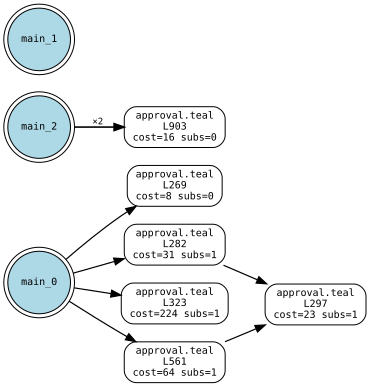

In [7]:
g, summaries = call_graph.build(xgov)
print(f"xgov call graph: {len(g.nodes)} nodes, {len(g.edges)} edges, {len(summaries)} subroutines")
svg = render_svg(call_graph.to_dot(xgov))
if svg:
    display(SVG(svg))
else:
    print("(no graphviz)")


## Recap

- Generic `TreeFold` framework — each analysis is ~50–150 lines.
- `loop_summary` body costs are now realistic (the
  `MAX_INNER_TXNS` multiplier in the previous Improper case was
  inflating numbers ~100×).
- `auth_dominance` evolved through three variants:
  - V1: ~28 unguarded on xgov, ~37 on folks-finance.
  - V2: ~2 on xgov, ~21 on folks-finance.
  - V3: ~2 on xgov, ~19 on folks-finance.
- Each iteration tightens the security signal by adding a deeper
  source of truth (structure → path predicates → caller context).

Next directions:
- Per-line PATH-list variants of `stack_depth` and `itxn_count`
  (mirror of `per_line_cost_paths`).
- Region-aware coverage analysis.
- Detect specific high-value patterns (e.g., `callsub` inside loops without guards).